# 03 - Enhance models

### 1. Importar librerías

In [1]:
import sys
import os
# sys.path.append(os.path.join(os.getcwd(), '../../src'))
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

import numpy as np
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

from src.utils import (
    load_data_npz,
    save_data_npz,
    build_model,
    unfreeze_backbone_layers,
    augmentar_dataset,
    train_model,
    evaluate_model,
    plot_learning_curves,
    plot_confusion_matrix,
    DATA_NPZ_PATH,
    DATA_AUG_NPZ_PATH,
    MODEL_PATH,
    FINETUNE_LAYERS,
    FINETUNE_LR,
    FINETUNE_EPOCHS
)


# Fine-tuning
Aplicar fine-tuning al mejor modelo descongalando capas y reentrenando con learning rate bajo.

### 2. Cargar datos

In [11]:
X_train, X_test, y_train, y_test = load_data_npz(DATA_NPZ_PATH)

# Redimensionar para Xception si aplica
X_train_xception = tf.image.resize(X_train, [299, 299]).numpy()
X_test_xception  = tf.image.resize(X_test,  [299, 299]).numpy()

print(f'Datos listos')
print(f'  X_train_xception: {X_train_xception.shape}')
print(f'  X_test_xception:  {X_test_xception.shape}')

Datos listos
  X_train_xception: (878, 299, 299, 3)
  X_test_xception:  (177, 299, 299, 3)


### 3. Cargar modelo preentrenado

In [13]:
# Cargar el modelo
# NOTA: Se puede reemplazar con el nombre del modelo guardado en la ruta:
# */src/model
model_name = 'Xception'
model_path = MODEL_PATH + model_name + '.keras'

if os.path.exists(model_path):
    model_ft = tf.keras.models.load_model(model_path)
    print(f'Modelo cargado desde: {model_path}')
else:
    print(f'Advertencia: modelo no encontrado en {model_path}')
    print('Por favor, asegúrate de haber entrenado y guardado el modelo primero.')

Modelo cargado desde: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception.keras


### 4. Descongelar capas para fine-tuning

In [14]:
# Descongelar las últimas capas del backbone
model_ft = unfreeze_backbone_layers(model_ft, num_layers=FINETUNE_LAYERS)

# Recompilar con learning rate bajo
model_ft.compile(
    optimizer=optimizers.Adam(FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'Modelo recompilado con lr={FINETUNE_LR}')

Capas entrenables en backbone: 25/132
Modelo recompilado con lr=1e-05


### 5. Entrenar con fine-tuning

In [15]:
history_ft = train_model(
    model_ft,
    X_train_xception,
    y_train,
    epochs=FINETUNE_EPOCHS,
    batch_size=16,  # Batch más pequeño para fine-tuning
    validation_split=0.15,
    patience=5
)

Epoch 1/20


47/47 [==============================] - 66s 1s/step - loss: 0.1110 - accuracy: 0.9665 - val_loss: 0.2884 - val_accuracy: 0.9015 - lr: 1.0000e-05
Epoch 2/20
47/47 [==============================] - 58s 1s/step - loss: 0.1134 - accuracy: 0.9611 - val_loss: 0.2970 - val_accuracy: 0.8864 - lr: 1.0000e-05
Epoch 3/20
47/47 [==============================] - ETA: 0s - loss: 0.0803 - accuracy: 0.9745
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
47/47 [==============================] - 58s 1s/step - loss: 0.0803 - accuracy: 0.9745 - val_loss: 0.3107 - val_accuracy: 0.8864 - lr: 1.0000e-05
Epoch 4/20
47/47 [==============================] - 58s 1s/step - loss: 0.0693 - accuracy: 0.9812 - val_loss: 0.3183 - val_accuracy: 0.8864 - lr: 5.0000e-06
Epoch 5/20
47/47 [==============================] - ETA: 0s - loss: 0.0722 - accuracy: 0.9786
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
47/47 [==============================] - 

### 6. Evaluar modelo con fine-tuning

In [16]:
result_ft = evaluate_model(
    model_ft,
    X_test_xception,
    y_test,
    model_name='Xception_finetuned'
)


  Xception_finetuned
Accuracy:  0.8136
AUC-ROC:   0.9221

Reporte de clasificación:
              precision    recall  f1-score   support

    sin_cara       0.79      0.88      0.83        92
        cara       0.85      0.74      0.79        85

    accuracy                           0.81       177
   macro avg       0.82      0.81      0.81       177
weighted avg       0.82      0.81      0.81       177



### 7. Visualizar resultados

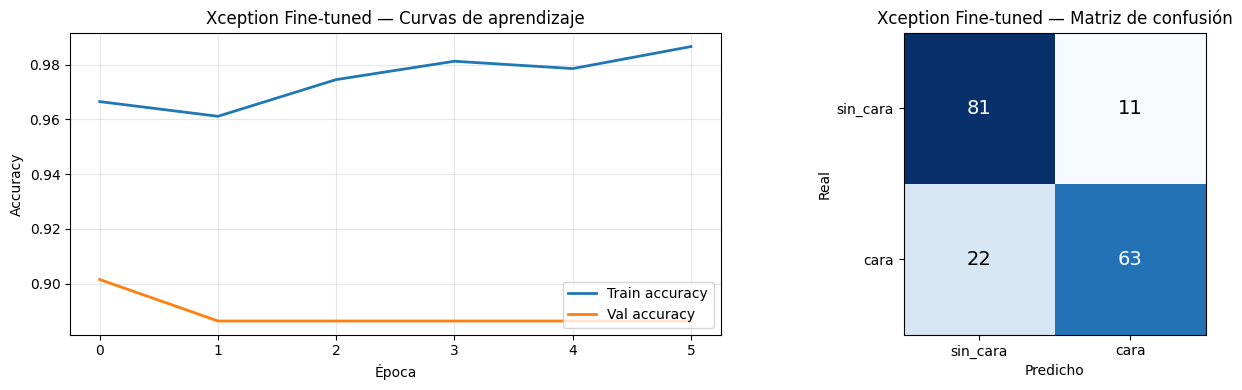

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_learning_curves(history_ft, 'Xception Fine-tuned', ax=axes[0])
plot_confusion_matrix(result_ft['confusion_matrix'], 'Xception Fine-tuned', ax=axes[1])

plt.tight_layout()
plt.show()

### 8. Guardar modelo fine-tuned

In [18]:
output_path = MODEL_PATH + 'Xception_finetuned.keras'
model_ft.save(output_path)
print(f'Modelo fine-tuned guardado en: {output_path}')

Modelo fine-tuned guardado en: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception_finetuned.keras


# Augmentation

Establecemos augmentations más fuertes para detectar mejor la clase 'sin_cara'

### 2. Cargar datos

In [16]:
X_train, X_test, y_train, y_test = load_data_npz(DATA_NPZ_PATH)

# Redimensionar para Xception si aplica
X_train_xception = tf.image.resize(X_train, [299, 299]).numpy()
X_test_xception  = tf.image.resize(X_test,  [299, 299]).numpy()

print(f'Datos listos')
print(f'  X_train_xception: {X_train_xception.shape}')
print(f'  X_test_xception:  {X_test_xception.shape}')

Datos listos
  X_train_xception: (878, 299, 299, 3)
  X_test_xception:  (177, 299, 299, 3)


### 3. Cargar modelo preentrenado

In [17]:
# Cargar el modelo
# NOTA: Se puede reemplazar con el nombre del modelo guardado en la ruta:
# */src/model
model_name = 'Xception'
model_path = MODEL_PATH + model_name + '.keras'

if os.path.exists(model_path):
    model_aug = tf.keras.models.load_model(model_path)
    print(f'Modelo cargado desde: {model_path}')
else:
    print(f'Advertencia: modelo no encontrado en {model_path}')
    print('Por favor, asegúrate de haber entrenado y guardado el modelo primero.')

Modelo cargado desde: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception.keras


### 4. Definimos augmentations

In [18]:
# Generador con augmentations agresivas
datagen = ImageDataGenerator(
    rotation_range=30,           # Rotación aleatoria de hasta 30 grados
    width_shift_range=0.2,       # Desplazamiento horizontal de hasta el 20% del ancho
    height_shift_range=0.2,      # Desplazamiento vertical de hasta el 20% del alto
    zoom_range=0.3,              # Zoom aleatorio de hasta el 30% (acerca o aleja)
    horizontal_flip=True,        # Volteo horizontal aleatorio
    brightness_range=[0.6, 1.4], # Variación de brillo entre el 60% y el 140% del original
    shear_range=0.2,             # Distorsión de cizallamiento de hasta 0.2 radianes
    fill_mode='nearest'          # Rellena los píxeles vacíos con el valor del píxel más cercano
)

X_train_aug, y_train_aug = augmentar_dataset(X_train_xception, y_train, datagen)

print(f'Train original: {X_train_xception.shape[0]} | Train aumentado: {X_train_aug.shape[0]}')
print(f'Caras: {(y_train_aug == 0).sum()} | Sin cara: {(y_train_aug == 1).sum()}')

Train original: 878 | Train aumentado: 1199
Caras: 557 | Sin cara: 642


In [19]:
# Guardar en formato .npz para carga rápida
save_data_npz(X_train_aug, X_test_xception, y_train_aug, y_test, DATA_AUG_NPZ_PATH)

Datos guardados en c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\data/data_aug.npz


### 5. Entrenamos modelo con augmentations

In [ ]:
# Carga rápida (si tenemos datos guardados)
X_train_aug, X_test, y_train_aug, y_test = load_data_npz(DATA_AUG_NPZ_PATH)

In [6]:
history_aug = train_model(
    model_aug,
    X_train_aug,
    y_train_aug,
    epochs=30,
    batch_size=32,  # Batch más pequeño para fine-tuning
    validation_split=0.15
)

Epoch 1/30


32/32 [==============================] - 62s 2s/step - loss: 0.4144 - accuracy: 0.8577 - val_loss: 0.1289 - val_accuracy: 0.9667 - lr: 2.5000e-05
Epoch 2/30
32/32 [==============================] - 57s 2s/step - loss: 0.1718 - accuracy: 0.9421 - val_loss: 0.1174 - val_accuracy: 0.9722 - lr: 2.5000e-05
Epoch 3/30
32/32 [==============================] - 56s 2s/step - loss: 0.1398 - accuracy: 0.9509 - val_loss: 0.1103 - val_accuracy: 0.9722 - lr: 2.5000e-05
Epoch 4/30
32/32 [==============================] - 58s 2s/step - loss: 0.1132 - accuracy: 0.9657 - val_loss: 0.1065 - val_accuracy: 0.9667 - lr: 2.5000e-05
Epoch 5/30
32/32 [==============================] - 58s 2s/step - loss: 0.1011 - accuracy: 0.9686 - val_loss: 0.1030 - val_accuracy: 0.9667 - lr: 2.5000e-05
Epoch 6/30
32/32 [==============================] - 57s 2s/step - loss: 0.0965 - accuracy: 0.9706 - val_loss: 0.1022 - val_accuracy: 0.9667 - lr: 2.5000e-05
Epoch 7/30
32/32 [==============================] - 56s 

### 6. Evaluar modelo augmented

In [11]:
result_aug = evaluate_model(
    model_aug,
    X_test,
    y_test,
    model_name='Xception_augmented'
)

ValueError: in user code:

    File "c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2381, in predict_step
        return self(x, training=False)
    File "c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from Non

### 7. Visualizar resultados

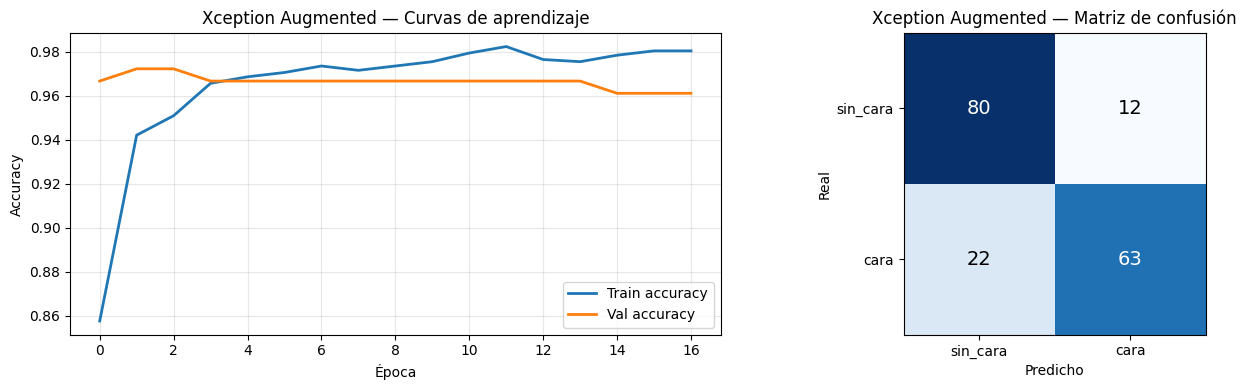

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_learning_curves(history_aug, 'Xception Augmented', ax=axes[0])
plot_confusion_matrix(result_aug['confusion_matrix'], 'Xception Augmented', ax=axes[1])

plt.tight_layout()
plt.show()

### 8. Guardar modelo fine-tuned

In [9]:
output_path = MODEL_PATH + 'Xception_augmented.keras'
model_aug.save(output_path)
print(f'Modelo fine-tuned guardado en: {output_path}')

Modelo fine-tuned guardado en: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception_augmented.keras


# Augmented + Fine Tuned Model

Es superimportante primero entrenar la cabeza con el backbone congelado para que los pesos nuevos sean razonables, y luego descongeladas las últimas capas para afinar. Si hacemos fine-tuning desde el principio con pesos aleatorios en la cabeza, los gradientes grandes pueden dañar los pesos preentrenados del backbone.

### 2. Cargar datos

In [2]:
# Carga rápida (si tenemos datos guardados)
X_train_aug_ft, X_test, y_train_aug_ft, y_test = load_data_npz(DATA_AUG_NPZ_PATH)

### 3. Cargar modelo preentrenado

In [3]:
# Cargar el modelo augmented
# NOTA: Se puede reemplazar con el nombre del modelo guardado en la ruta:
# */src/model
model_name = 'Xception_augmented'
model_path = MODEL_PATH + model_name + '.keras'

if os.path.exists(model_path):
    model_aug = tf.keras.models.load_model(model_path)
    print(f'Modelo cargado desde: {model_path}')
else:
    print(f'Advertencia: modelo no encontrado en {model_path}')
    print('Por favor, asegúrate de haber entrenado y guardado el modelo primero.')



Modelo cargado desde: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception_augmented.keras


### 4. Fine-tuning sobre el modelo augmented

In [4]:
# Descongelar las últimas capas del backbone
model_aug_ft = unfreeze_backbone_layers(model_aug, num_layers=FINETUNE_LAYERS)

# Recompilar con learning rate bajo
model_aug_ft.compile(
    optimizer=optimizers.Adam(FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'Modelo recompilado con lr={FINETUNE_LR}')

Capas entrenables en backbone: 25/132
Modelo recompilado con lr=1e-05


### 5. Entrenamos modelo

In [5]:
history_aug_ft = train_model(
    model_aug_ft,
    X_train_aug_ft,
    y_train_aug_ft,
    epochs=FINETUNE_EPOCHS,
    batch_size=16,  # Batch más pequeño para fine-tuning
    validation_split=0.15,
    patience=5
)

Epoch 1/20


64/64 [==============================] - 87s 1s/step - loss: 0.1767 - accuracy: 0.9254 - val_loss: 0.0647 - val_accuracy: 0.9722 - lr: 1.0000e-05
Epoch 2/20
64/64 [==============================] - 78s 1s/step - loss: 0.1271 - accuracy: 0.9568 - val_loss: 0.0735 - val_accuracy: 0.9722 - lr: 1.0000e-05
Epoch 3/20
64/64 [==============================] - ETA: 0s - loss: 0.1258 - accuracy: 0.9549
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
64/64 [==============================] - 79s 1s/step - loss: 0.1258 - accuracy: 0.9549 - val_loss: 0.0819 - val_accuracy: 0.9611 - lr: 1.0000e-05
Epoch 4/20
64/64 [==============================] - 79s 1s/step - loss: 0.0965 - accuracy: 0.9627 - val_loss: 0.0818 - val_accuracy: 0.9611 - lr: 5.0000e-06
Epoch 5/20
64/64 [==============================] - ETA: 0s - loss: 0.0787 - accuracy: 0.9706
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
64/64 [==============================] - 

### 6. Evaluar modelo

In [6]:
result_aug_ft = evaluate_model(
    model_aug_ft,
    X_test,
    y_test,
    model_name='Xception_augmented_finetuned'
)


  Xception_augmented_finetuned
Accuracy:  0.8136
AUC-ROC:   0.9047

Reporte de clasificación:
              precision    recall  f1-score   support

    sin_cara       0.79      0.88      0.83        92
        cara       0.85      0.74      0.79        85

    accuracy                           0.81       177
   macro avg       0.82      0.81      0.81       177
weighted avg       0.82      0.81      0.81       177



### 7. Visualizar resultados

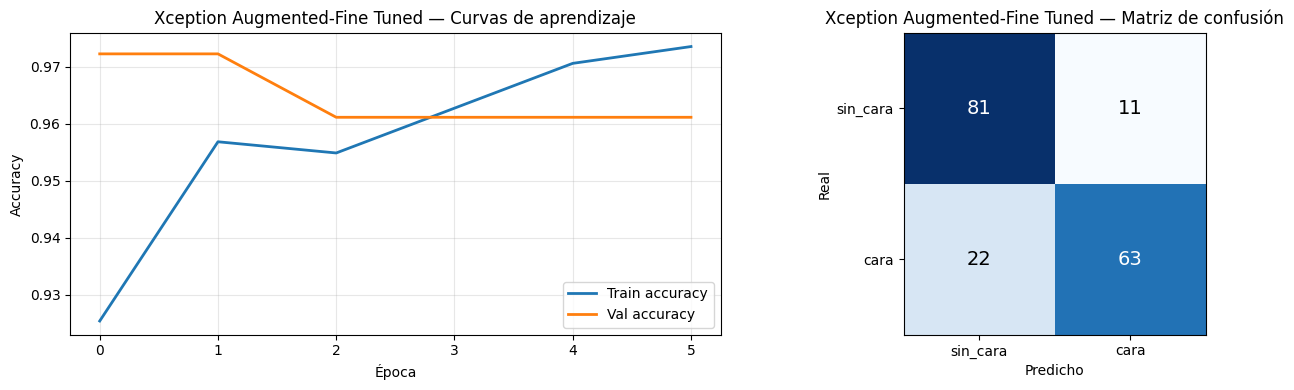

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_learning_curves(history_aug_ft, 'Xception Augmented-Fine Tuned', ax=axes[0])
plot_confusion_matrix(result_aug_ft['confusion_matrix'], 'Xception Augmented-Fine Tuned', ax=axes[1])

plt.tight_layout()
plt.show()

### 8. Guardar modelo Augmented-Fine Tuned

In [8]:
output_path = MODEL_PATH + 'Xception_augmented_finetuned.keras'
model_aug_ft.save(output_path)
print(f'Modelo fine-tuned guardado en: {output_path}')

Modelo fine-tuned guardado en: c:\Users\urkow\Documents\Documentos_Clase\Ants_trajectories_ML\src/model/Xception_augmented_finetuned.keras
